NOTA PREVIA: El ejercicio que se muestra en este Notebook pretende servir de referencia al alumnado sobre lo que se espera (a nivel de implementación, análisis de resultados y explicación del trabajo realizado) a la hora de abordar un ejercicio de una práctica de la asignatura. Evidentemente, la respuesta proporcionada en este Notebook, para el ejercicio de ejemplo, no es la única válida; y, por otro lado, cada ejercicio es diferente y se puede abordar de formas distintas. Lo que es innegociable es intentar explicar con la mayor claridad posible qué se ha hecho, por qué se ha hecho así, qué resultados se han obtenido, y qué conclusiones se extraen en base a estos resultados. Del mismo modo, tal y como se muestra en este mismo Notebook, cualquier experimentación extra, o análisis adicional, que se realice será valorado positivamente. Se recomienda dejar claro que se entiende lo que se ha hecho, así como poner en valor el esfuerzo realizado y lo que se ha aprendido.

In [ ]:
# We start by getting access to the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# We import the modules to use
import os,sys
import cv2, numpy as np, math
from matplotlib import pyplot as plt
# change directory
%cd '/content/drive/My Drive'
#  the current directory
%pwd

# This allows to display images  and to save  them in cells
%matplotlib inline
# this definition allows to read files in a specific path
get_image = lambda route: os.path.join('/content/drive/My Drive/images', route)

/content/drive/My Drive


#Ejercicio de ejemplo

El alumnado debe implementar el método de umbralización de Otsu (minimizando la varianza intra-clase), y debe verificar su correcto funcionamiento realizando la binarización de la imagen `zebra.jpg` (leída en escala de grises). Junto con lo anterior, se debe proporcionar un gráfico que muestre, en el eje $X$, el valor de intensidad de pixel y, en el eje $Y$, la varianza interclase. Se debe marcar con una línea negra vertical el punto en donde esta varianza se mimimiza (destacando, de ese modo, el umbral encontrado).


<font color="blue">En primer lugar, se procede a explicar, brevemente, en qué consiste el método de Otsu (publicado por Nobuyuki Otsu en 1979, en el artículo "A threshold selection method from gray-level histograms". IEEE Transactions on Systems, Man, and Cybernetics. 9 (1): 62-66).

<font color="blue">Otsu propone iterar a través de todos los posibles valores de umbral ($0-255$) y medir la varianza de los píxeles del fondo ($\textit{background}$) y del primer plano ($\textit{foreground}$). A continuación, propone elegir como umbral óptimo el valor que proporciona la menor varianza intra-clase. Se busca que ambos clusters estén muy cohesionados internamente. Minimizar la varianza intra-clase es equivalente a maximizar la varianza inter-clase pero, como en el enunciado se indica explícitamente que se debe minimizar la varianza intra-clase, esto es lo que se hace en este ejercicio. La intuición subyacente se basa en el hecho de que un buen umbral es aquél que separa, lo más posible, la distribución de intensidades de las dos clases (siendo cada clase lo más homogénea posible internamente y lo más diferente posible externamente).

<font color="blue"> A nivel matemático podríamos plantearlo como se muestra a continuación (empleando como referencia las indicaciones proporcionadas en clase de teoría a partir de https://muthu.co/otsus-method-for-image-thresholding-explained-and-implemented/).  

<font color="blue"> Lo que buscamos minimizar es
$$
\sigma^2_{\text{intra}}(t)=\omega_{bg}(t)\,\sigma_{bg}^2(t)+\omega_{fg}(t)\,\sigma_{fg}^2(t)
$$
en donde $bg$ y $fg$ hacen referencia al $\textit{background}$ (píxeles del fondo) y $\textit{foreground}$ (primer plano), respectivamente. Para comprender la expresión anterior, primero debemos definir una serie de elementos. En primer lugar, $P_{all}$ sería el  número total de píxeles en la imagen. Y, para cada posible umbral $t$, tendríamos:

<font color="blue"> $P_{bg}(t)$ = número de píxeles con intensidad < t (clase $\textit{background}$).

<font color="blue"> $P_{fg}(t)$ = número de píxeles con intensidad ≥ t (clase $\textit{foreground}$).

<font color="blue"> En cuanto hemos definido los tres elementos anteriores, ya podemos presentar los pesos / probabilidades de cada clase:
  $$
  \omega_{bg}(t)=\frac{P_{bg}(t)}{P_{all}},\qquad
  \omega_{fg}(t)=\frac{P_{fg}(t)}{P_{all}}=1-\omega_{bg}(t).
  $$

<font color="blue"> A continuación, calcularíamos la media de cada clase ($\mu_{bg}(t)$ y $\mu_{fg}(t)$), sumando todos los valores de intensidad de los píxeles pertenecientes a la clase ($\textit{foreground}$ o $\textit{background}$) y dividiendo por el número de píxeles de dicha clase. Y, en base a esta media, calcularíamos la varianza para cada clase ($\sigma_{bg}^2(t)$ y $\sigma_{fg}^2(t)$).

<font color="blue"> Es importante remarcar que la varianza inter-clase sería
$$
\sigma^2_{\text{inter}}(t) \;=\; \omega_{bg}(t)\,\omega_{fg}(t)\,\big(\mu_{bg}(t)-\mu_{fg}(t)\big)^2.
$$
Y que
$$
\arg\min_t \sigma^2_{\text{intra}}(t) \;=\; \arg\max_t \sigma^2_{\text{inter}}(t).
$$
siendo $\sigma^2_{\text{intra}}(t)$ la expresión que estamos empleando en este ejercicio. Las dos formulaciones (min-intra o max-inter) conducen al mismo umbral óptimo teórico de Otsu.

<font color="blue"> Toda esta explicación, incluyendo los elementos matemáticos, son conocidos, populares y de fácil acceso. Incluso la entrada de Wikipedia lo muestra con claridad (https://en.wikipedia.org/wiki/Otsu%27s_method).



<font color="blue"> Para la realización de este ejercicio se ha empleado ChatGPT, en su versión GPT-5, por medio del siguiente prompt inicial (que ha sido progresivamente refinado hasta obtener algo próximo al resultado buscado):

<font color="blue"> ```Necesito código Python ejecutable en Google Colab que implemente el método de umbralización de Otsu, y que permita binarizar una imagen y, al mismo tiempo, proporcionar un gráfico que muestre, en el eje X el valor de intensidad de pixel y en el eje Y la varianza interclase. Se debe marcar con una línea negra vertical el punto en donde esta varianza se maximiza. El código debe estar comentado línea por línea, y se debe proporcionar una explicación teórica y metodológica del funcionamiento del método de Otsu (1979). La lectura de la imagen de entrada se realiza con im=cv2.imread(get_image('zebra.jpg'),0).astype(np.float32) que ya permite leer en float32 y escala de grises la imagen de entrada.```



<font color="blue"> El resultado proporcionado por ChatGPT fue modificado y adaptado del siguiente modo:
- Como mi prompt no fue todo lo preciso que debería, y yo mismo hablo de que "esta varianza se maximiza", ChatGPT presentó una solución basada en maximizar la varianza inter-clase, que no es lo que se pide en el enunciado, y empleando unas expresiones matemáticas no explicadas en clase. Esto hubo que modificarlo y adaptarlo, de modo que se cumpliese de una forma más fiel la letra y el espíritu de lo indicado en el enunciado.
- El código proporcionado guardaba en disco las imágenes resultantes (algo no permitido en la asignatura).
- A continuación, se procedió a adaptar la explicación teórica proporcionada por ChatGPT a lo explicado en clase, y lo empleado en la referencia online mostrada en los materiales de la asignatura (https://muthu.co/otsus-method-for-image-thresholding-explained-and-implemented/).
- A nivel de texto y redacción, se realizaron numerosas modificaciones en relación a lo proporcionado por ChatGPT, dado que estos LLMs tienden a proporcionar un texto excesivamente formateado, abusando por momentos de las negritas, los emoticonos, las cursivas y expresiones poco naturales en castellano.
- Se revisó línea por línea el código simplificándolo, dado que ChatGPT proporcionó una implementación demasiado verbosa y, por momentos, innecesariamente compleja. Por ejemplo, OpenCV empleaba `cv2.calcHist` y `np.cumsum` que, a mi juicio, no son imprescindibles de cara a resolver el ejercicio. Es cierto que la ejecución del código, al eliminar estas funciones optimizadas se ralentizó bastante, pero con la contraprestación de simplificar el código y aproximarlo más a lo visto en teoría. Otro elemento que se simplificó, por ejemplo, fue el hecho de que ChatGPT normalizaba la imagen a $0..255$ en caso de que los valores no estuviesen ya en ese rango. Esto se consideró innecesario, y se asumió que las imágenes que se iban a leer iban a estar, por defecto, en ese intervalo. De ese modo, se simplificaba más el código, facilitando su comprensión. Otro elemento modificado fue que ChatGPT realizaba múltiples $\textit{casts}$ a $\textit{float}$, que consideré innecesarios/redundantes, complicando el código de forma injustificada. </font>


In [ ]:
im=cv2.imread(get_image('zebra.jpg'),0).astype(np.float32)

In [ ]:
H, W = im.shape              # dimensiones
N = H * W                    # número total de píxeles (float para divisiones)

In [ ]:
# Reservamos arrays para guardar los resultados por cada umbral t
w_bg_arr = np.zeros(256, dtype=np.float64)
w_fg_arr = np.zeros(256, dtype=np.float64)
mu_bg_arr = np.zeros(256, dtype=np.float64)
mu_fg_arr = np.zeros(256, dtype=np.float64)
var_bg_arr = np.zeros(256, dtype=np.float64)
var_fg_arr = np.zeros(256, dtype=np.float64)
sigma_intra_arr = np.zeros(256, dtype=np.float64)

In [ ]:
img_flat = im.ravel()                  # vector 1D con todos los píxeles

In [ ]:
import time
from datetime import timedelta
starttime = time.perf_counter()

# Iteramos explícitamente por cada umbral t
for t in range(256):
    # máscara de fondo: intensidades <= t
    mask_bg = (img_flat <= t)
    # máscara de primer plano: intensidades > t
    mask_fg = ~mask_bg

    # conteos de píxeles en cada clase (enteros)
    P_bg = np.count_nonzero(mask_bg)      # número píxeles fondo
    P_fg = img_flat.size - P_bg          # número píxeles primer plano

    # pesos (probabilidades) de cada clase
    w_bg = P_bg / N
    w_fg = P_fg / N

    # inicializar medias y varianzas en caso de clase vacía
    mu_bg = 0.0
    mu_fg = 0.0
    var_bg = 0.0
    var_fg = 0.0

    # si hay píxeles en fondo, calcular media y varianza
    if P_bg > 0:
        # suma de intensidades de los píxeles del fondo
        sum_bg = img_flat[mask_bg].sum()
        # media del fondo: suma de intensidades / número de píxeles del fondo
        mu_bg = sum_bg / P_bg
        # varianza: (1/P_bg) * sum (i - mu_bg)^2
        diff_bg = img_flat[mask_bg].astype(np.float64) - mu_bg
        var_bg = (diff_bg * diff_bg).sum() / P_bg

    # si hay píxeles en primer plano, calcular media y varianza
    if P_fg > 0:
        sum_fg = img_flat[mask_fg].sum()
        mu_fg = sum_fg / P_fg
        diff_fg = img_flat[mask_fg].astype(np.float64) - mu_fg
        var_fg = (diff_fg * diff_fg).sum() / P_fg

    # varianza intraclase ponderada, siguiendo la expresión matemática explicada en la asignatura
    sigma_intra = w_bg * var_bg + w_fg * var_fg

    # guardar resultados
    w_bg_arr[t] = w_bg
    w_fg_arr[t] = w_fg
    mu_bg_arr[t] = mu_bg
    mu_fg_arr[t] = mu_fg
    var_bg_arr[t] = var_bg
    var_fg_arr[t] = var_fg
    sigma_intra_arr[t] = sigma_intra

duration_otsu_manual = timedelta(seconds=time.perf_counter() - starttime)

In [ ]:
# Encontrar el umbral que minimiza la varianza intraclase
t_best = int(np.argmin(sigma_intra_arr))
print(f"Umbral que minimiza sigma_intra: {t_best}")
otsu_intra = t_best

Umbral que minimiza sigma_intra: 94


<font color="blue"> A continuación, aunque no se pide explícitamente en el enunciado, se decide comparar los resultados obtenidos por nuestra implementación manual (guiada por ChatGPT) con los proporcionados por OpenCV al utilizar la función de umbralización de Otsu ya incluida en la librería. El principal motivo es verificar el correcto funcionamiento de nuestra implementación por medio de la comparación con la librería de referencia, tanto del resultado visual final como del umbral óptimo identificado. Esto nos ayudará a encontrar errores o problemas en nuestra implementación.

<font color="blue"> En https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html se indica con claridad cómo opera esta función. En concreto, cuando hacemos:
```python
_, th = cv2.threshold(im_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```
* <font color="blue"> `im_8u` es la imagen de entrada, que debe ser de un solo canal (escala de grises). En https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57 se indica con claridad que *"Currently, the Otsu's method is implemented only for CV_8UC1 and CV_16UC1 images"*. `CV_8UC1` se refiere a imágenes de 8 bits sin signo ("U" por unsigned), con un solo canal ("C1"). Esto significa que cada píxel se representa con un número entero entre 0 y 255 (el formato estándar para imágenes en escala de grises).

* <font color="blue"> `0` (segundo argumento: `thresh`). En un uso normal (sin Otsu), este sería el valor del umbral fijo. Por ejemplo, si pusiese `127`, entonces todo píxel mayor que $127$ se convertiría en $255$, y el resto se convertiría en $0$. No obstante,  cuando añades `cv2.THRESH_OTSU` en el cuarto argumento, este valor se ignora (OpenCV lo sobreescribe con el umbral óptimo que calcule Otsu). Es decir, al usar Otsu, se puede poner cualquier número porque no afecta. Yo he incluido un $0$.

* <font color="blue"> `255` (tercer argumento: `maxval`). Es el valor que se asigna a los píxeles que cumplen la condición de ser mayores que el umbral. En binarización clásica, se pone 255 (blanco).

* <font color="blue"> `cv2.THRESH_BINARY + cv2.THRESH_OTSU` (cuarto argumento: `type`). Esto controla el modo de umbralización. `cv2.THRESH_BINARY` significa que píxeles > umbral → `maxval` (ej. 255), y píxeles ≤ umbral → 0. Es decir, indicamos que es una umbralización binaria (dos clases). `cv2.THRESH_OTSU`  indica que se elige automáticamente el valor de umbral óptimo según el método de Otsu. Al sumar ambas instrucciones lo que estamos haciendo es indicar a OpenCV que use el modo binario junto con la selección de umbral automática de Otsu.

<font color="blue"> La función devuelve dos cosas: el umbral usado finalmente y la imagen binarizada (mismo tamaño que la original, pero solo con dos valores: ceros o `maxval`).



In [ ]:
# Binarizar con el umbral obtenido por minimización intra-clase
bin_intra = np.where(im > otsu_intra, 255, 0).astype(np.uint8)

# -------------------- Otsu de OpenCV (nuestra referencia) --------------------
# Convert the image to 8-bit unsigned integer type for OpenCV Otsu
im_8u = im.astype(np.uint8)

starttime = time.perf_counter()
otsu_cv2_val, bin_cv2 = cv2.threshold(im_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
otsu_cv2 = int(otsu_cv2_val)
duration_otsu_opencv = timedelta(seconds=time.perf_counter() - starttime)

In [ ]:
# -------------------- Comparación pixel a pixel --------------------
equal_mask = (bin_intra == bin_cv2)
diff_mask = ~equal_mask

n_pixels = im.size
n_equal = np.count_nonzero(equal_mask)
n_diff = np.count_nonzero(diff_mask)
pct_diff = 100.0 * n_diff / n_pixels

# Calculamos métricas sencillas para verificar si nuestra clasificación binaria
# (fondo vs primer plano) difiere mucho de lo proporcionado por OpenCV
tp = np.count_nonzero((bin_intra == 255) & (bin_cv2 == 255))
tn = np.count_nonzero((bin_intra == 0) & (bin_cv2 == 0))
fp = np.count_nonzero((bin_intra == 255) & (bin_cv2 == 0))
fn = np.count_nonzero((bin_intra == 0) & (bin_cv2 == 255))

In [ ]:
# -------------------- Resultados numéricos --------------------
print("=== Resultados ===")
print(f"Umbral (varianza intra-clase mínima): {otsu_intra}")
print(f"Umbral (OpenCV Otsu): {otsu_cv2}")
print(f"Píxeles iguales entre binarizaciones: {n_equal} / {n_pixels} ({100.0 * n_equal / n_pixels:.1f}%)")
print(f"Píxeles distintos: {n_diff} ({pct_diff:.1f}%)")
print("\nMétricas (manual vs OpenCV) - TP (True Positives), TN (True Negatives), FP (False Positives), FN (False Negatives)")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

=== Resultados ===
Umbral (varianza intra-clase mínima): 94
Umbral (OpenCV Otsu): 94
Píxeles iguales entre binarizaciones: 2764800 / 2764800 (100.0%)
Píxeles distintos: 0 (0.0%)

Métricas (manual vs OpenCV) - TP (True Positives), TN (True Negatives), FP (False Positives), FN (False Negatives)
TP: 2098732, TN: 666068, FP: 0, FN: 0


In [ ]:
print('Tiempo implementación manual: ' + str(duration_otsu_manual) + ' | Tiempo implementación OpenCV: ' + str(duration_otsu_opencv))
# Convertir los objetos timedelta a segundos para el cálculo
time_manual_sec = duration_otsu_manual.total_seconds()
time_opencv_sec = duration_otsu_opencv.total_seconds()
# Calcular el factor de aceleración
acceleration_factor = time_manual_sec / time_opencv_sec
print(f'Factor de aceleración de OpenCV con respecto a mi código: {acceleration_factor:.1f}')

Tiempo implementación manual: 0:00:10.717513 | Tiempo implementación OpenCV: 0:00:00.003420
Factor de aceleración de OpenCV con respecto a mi código: 3133.8


<font color="blue"> Se puede observar que mi código es $>3000$ veces más lento que el de OpenCV (aunque, dependiendo de la ejecución concreta, el factor exacto puede variar mucho). Esto es debido a que NumPy y OpenCV están altamente optimizadas, y en mi código he optado por realizar una implementación sencilla (priorizando claridad y sencillez a eficiencia). Como ni en el enunciado ni en clase se ha exigido ningún requisito de eficiencia, en un principio, se deja el código como está (teniendo en cuenta, además, que el tiempo de ejecución para la imagen solicitada en el enunciado, entra dentro de lo razonable: unos $7$-$10$ segundos), y solo se propone una subsección extra final con una primera versión optimizada del código.

<font color="blue"> A continuación, se realiza la visualización de resultados: se muestra la imagen original, la imagen resultante de la umbralización utilizando la implementación manual, la imagen resultante de la umbralización utilizando la implementación de OpenCV, un mapa de disparidad entre píxeles resultantes de aplicar una implementación u otra, y la gráfica que muestra el umbral escogido (valores de nivel de gris VS varianza intra-clase).

<font color="blue"> Se opta por emplear `gridspec` para organizar los $subplots$ de manera flexible dentro de una figura. En concreto, se emplea
```python
from matplotlib import gridspec
gs = gridspec.GridSpec(2, 3, height_ratios=[1,1.1], width_ratios=[1,1,1])
```
<font color="blue"> en donde, `GridSpec(2, 3)` crea una rejilla de $2$ filas y $3$ columnas para colocar los $subplots$; `height_ratios=[1,1.1]` indica que la segunda fila será un poco más alta que la primera (proporción $1:1.1$); y `width_ratios=[1,1,1]` significa que las tres columnas tienen la misma anchura. Con esto, no estamos limitados a un $layout$ uniforme y se pueden ajustar con facilidad tamaños relativos de filas y columnas.

<font color="blue"> Después, cada $subplot$ se coloca usando la sintaxis:
```python
ax0 = plt.subplot(gs[0,0])  # fila 0, columna 0
ax1 = plt.subplot(gs[0,1])  # fila 0, columna 1
ax2 = plt.subplot(gs[0,2])  # fila 0, columna 2
ax3 = plt.subplot(gs[1,0])  # fila 1, columna 0
ax4 = plt.subplot(gs[1,1:]) # fila 1, columnas 1 y 2
```

<font color="blue"> `gs[0,0]` hace referencia al primer $subplot$, fila $0$, columna $0$.

<font color="blue"> `gs[1,1:]` ocupa la fila $1$ y las columnas $1$ y $2$, es decir, ocupa $2$ columnas.

<font color="blue"> Esto permite tener $layouts$ irregulares, o combinar varias celdas para un $subplot$ más ancho, tal y como vemos a continuación.

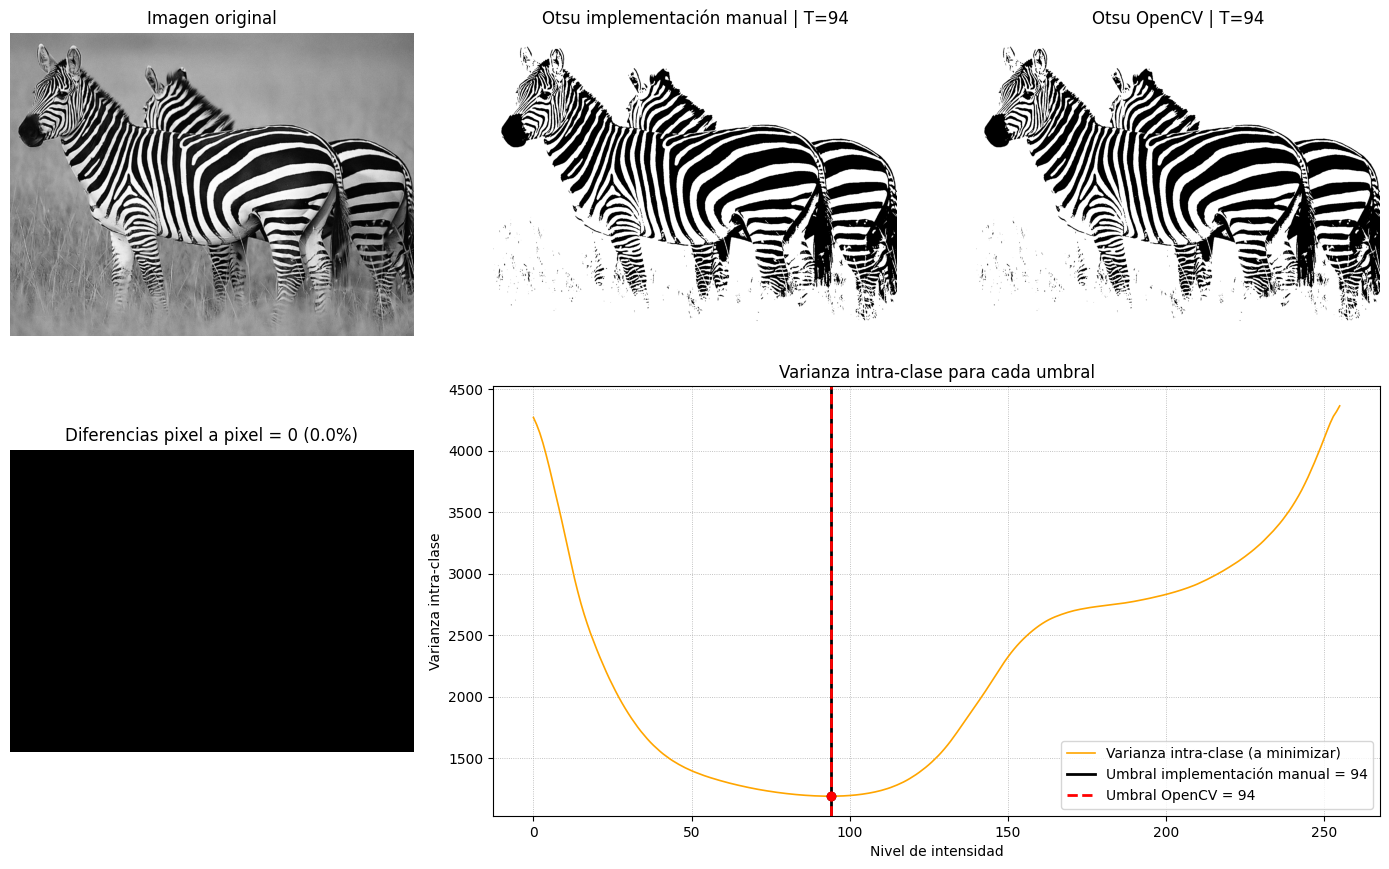

In [ ]:
# -------------------- Visualización --------------------
plt.figure(figsize=(14,9))
from matplotlib import gridspec
gs = gridspec.GridSpec(2, 3, height_ratios=[1,1.1], width_ratios=[1,1,1])

# Original
ax0 = plt.subplot(gs[0,0])
ax0.imshow(im, cmap='gray', vmin=0, vmax=255)
ax0.set_title('Imagen original')
ax0.axis('off')

# Binarizada (minim. intra-clase)
ax1 = plt.subplot(gs[0,1])
ax1.imshow(bin_intra, cmap='gray', vmin=0, vmax=255)
ax1.set_title(f'Otsu implementación manual | T={otsu_intra}')
ax1.axis('off')

# Binarizada OpenCV
ax2 = plt.subplot(gs[0,2])
ax2.imshow(bin_cv2, cmap='gray', vmin=0, vmax=255)
ax2.set_title(f'Otsu OpenCV | T={otsu_cv2}')
ax2.axis('off')

# Diferencias
ax3 = plt.subplot(gs[1,0])
diff_vis = diff_mask.astype(np.uint8) * 255
ax3.imshow(diff_vis, cmap='gray', vmin=0, vmax=255)
ax3.set_title(f'Diferencias pixel a pixel = {n_diff} ({pct_diff:.1f}%)')
ax3.axis('off')

# Curvas: varianza intra-clase por cada umbral
ax4 = plt.subplot(gs[1,1:])
ax4.plot(np.arange(256), sigma_intra_arr, label='Varianza intra-clase (a minimizar)', color='orange', linewidth=1.2)
ax4.set_xlabel('Nivel de intensidad')
ax4.set_ylabel('Varianza intra-clase')
ax4.set_title('Varianza intra-clase para cada umbral')
ax4.grid(True, linestyle=':', linewidth=0.6)
# marcas
ax4.axvline(otsu_intra, color='black', linewidth=2.0, label=f'Umbral implementación manual = {otsu_intra}')
ax4.axvline(otsu_cv2, color='red', linestyle='--', linewidth=2.0, label=f'Umbral OpenCV = {otsu_cv2}')
ax4.plot(otsu_intra, sigma_intra_arr[otsu_intra], 'ko')
if 0 <= otsu_cv2 < 256:
    ax4.plot(otsu_cv2, sigma_intra_arr[otsu_cv2], 'ro')
ax4.legend()

plt.tight_layout()
plt.show()

<font color="blue"> Los resultado obtenidos parecen razonables. Por un lado, la umbralización obtenida con la implementación manual coincide a la perfección con la proporcionada por la implementación de OpenCV (pixel a pixel). La gráfica muestra con claridad que se ha elegido como umbral el mismo valor de OpenCV que, a su vez, es el que minimiza la varianza intra-clase. La comparación con la función de OpenCV ofrece una diferencia de $0.0\%$ de los píxeles. En cualquier caso, se percibe que nuestra umbralización tiene sentido, mostrando en negro los valores más oscuros y en blanco los más claros, siguiendo un patrón lógico y esperable, y permitiendo identificar perfectamente ambas cebras.

## <font color="blue">  Extra: optimización del código implementado

<font color="blue"> En esta subsección se muestra una posible optimización del código realizado en el ejercicio. Lo he obtenido tras refinar la respuesta de ChatGPT, obtenida al pasarle el código anterior e indicarle lo siguiente: `El código funciona perfectamente bien, pero es muy lento. Quiero exactamente el mismo código pero optimizado por medio de vectorización de NumPy. Quiero que el código siga minimizando la varianza intra-clase, y que siga usando explícitamente la expresión sigma_intra = w_bg * var_bg + w_fg * var_fg`.

<font color="blue"> La clave de la implementación proporcionada por ChatGPT, y refinada por mí, reside en evitar el bucle `for` y emplear, dentro de lo posible, operaciones vectorizadas. Es decir, en lugar de recorrer todos los píxeles para cada umbral, construimos el histograma `hist` y, a partir de él, calculamos sumas acumuladas: `cum_counts`, `cum_sum` y `cum_sq`. Con esas tres cantidades se pueden obtener, para cada umbral $t$, las cantidades necesarias `(P_bg, sum_bg, sum_sq_bg)` y, por diferencia, las correspondientes del primer plano, en un solo pase vectorizado. Las varianzas, de hecho, ChatGPT propuso calcularlas basándose en la identidad
  $$
  \operatorname{Var} = \frac{\sum x^2}{P} - \mu^2,
  $$
que contribuye a evitar tener que hacer bucles sobre los píxeles. En la expresión anterior, $P$ sería el número de píxeles pertenecientes a la clase en cuestión (fondo o primer plano), $x^2$ es el cuadrado de cada uno de los elementos de la clase, y $\mu^2$ es la media al cuadrado. A continuación, lo muestro con un pequeño ejemplo. Si empleamos $[2,4]$, tendríamos:

<font color="blue"> Media = $(2+4)/2 = 3$.

<font color="blue"> Varianza = $\frac{(2-3)^2 + (4-3)^2}{2} = 1$.

<font color="blue"> De este modo, calcularíamos la media, y luego recorreríamos todos los píxeles para restar la media, elevar al cuadrado, sumar y dividir por el número de píxeles/elementos.

<font color="blue"> En cambio, con la expresión indicada más arriba tendríamos:
$$
Var = \frac{(2^2 + 4^2)}{2} - 3^2 = \frac{20}{2} - 9 = 10 - 9 = 1
$$
De este modo, tenemos que calcular la media, sumamos todos los píxeles al cuadrado (sin restarles nada), dividimos por el número de píxeles y restamos la media.



<font color="blue"> Profundizo un poco más en algunos aspectos clave de la nueva implementación. Es importante tener presente que, para cada posible umbral $t$, queremos:
* <font color="blue"> El número de píxeles en fondo y primer plano: $P_{bg}(t)$, $P_{fg}(t)$.
* El peso de cada clase: $w_{bg}(t)$ y $w_{fg}(t)$
* La media de cada clase:
  $$
  \mu_{bg}(t) = \frac{\sum_{x_i \leq t} x_i}{P_{bg}(t)}, \quad
  \mu_{fg}(t) = \frac{\sum_{x_i > t} x_i}{P_{fg}(t)}
  $$
* La varianza de cada clase (en este caso, mostramos solo la del fondo a modo de ejemplo):
  $$
  \sigma^2_{bg}(t) = \frac{\sum_{x_i \leq t} (x_i - \mu_{bg}(t))^2}{P_{bg}(t)}
  $$

<font color="blue"> La clave aquí es que esto hay que hacerlo para cada $t=0,1,\dots,255$. Y esto, como ya se ha comprobado, es muy lento. Entonces, en aras de encontrar una implementación más eficiente, vamos a trabajar con histogramas y acumulados. Es decir, en lugar de recorrer todos los píxeles cada vez, observamos que lo único que importa son cuántos píxeles tienen intensidad $i$. Ese es justamente el histograma:
$$
hist[i] = \text{número de píxeles con intensidad } i
$$
Y con ese histograma podemos calcular acumulados hasta un umbral $t$.

<font color="blue"> Revisemos algunas de las variables clave en esta nueva implementación:





<font color="blue"> `cum_sum`
$$
cum\_sum[t] = \sum_{i=0}^t hist[i] \cdot i
$$
Suma de intensidades ≤ t.
Esto da el numerador de $\mu_{bg}(t)$.



<font color="blue"> `total_sum`
$$
\text{total_sum} = \sum_{i=0}^{255} hist[i] \cdot i
$$
Suma de todas las intensidades de la imagen, que nos permite calcular rápidamente el $\textit{foreground}$:
$$
\sum_{x_i > t} x_i = \text{total_sum} - \text{cum_sum}[t]
$$



<font color="blue"> `total_sq`
$$
\text{total_sq} = \sum_{i=0}^{255} hist[i] \cdot i^2
$$
Suma de los cuadrados de intensidades de toda la imagen.
Esto es necesario porque, como indicaba antes, la varianza puede expresarse como:
$$
Var = \frac{\sum x^2}{P} - \mu^2
$$
Así que necesitamos saber, en cada clase, cuánto vale $\sum x^2$. Veamos un ejemplo numérico sencillo para entenderlo mejor. Supongamos una mini imagen de 5 píxeles y 5 posibles valores de intensidad ($\{0,1,2,3,4\}$):
$$
[2, 2, 3, 3, 3]
$$

<font color="blue"> El histograma contendría:
  ```
  hist[0] = 0
  hist[1] = 0
  hist[2] = 2
  hist[3] = 3
  hist[4] = 0
  ```
<font color="blue"> Si hacemos la suma de cuadrados, recorriendo los píxeles de la imagen, obtendríamos:
  $$
  2^2 + 2^2 + 3^2 + 3^2 + 3^2 = 4 + 4 + 9 + 9 + 9 = 35
  $$

<font color="blue"> Empleando la expresión que utiliza el histograma tendríamos lo siguiente:
  $$
  \sum_{i=0}^{4} hist[i] \cdot i^2 = hist[0]*0^2 + hist[1]*1^2 + hist[2]*2^2 + hist[3]*3^2 + ... = 2*4 + 3*9 = 35
  $$



<font color="blue"> `cum_counts`
$$
cum\_counts[t] = \sum_{i=0}^t hist[i]
$$
Es el número de píxeles con intensidad ≤ t, es decir, $P_{bg}(t)$.



<font color="blue"> `cum_sq`
$$
cum\_sq[t] = \sum_{i=0}^t hist[i] \cdot i^2
$$
Es la suma de cuadrados ≤ t, que nos proporciona el numerador de la varianza para la clase fondo:
$$
\sigma^2_{bg}(t) = \frac{cum\_sq[t]}{P_{bg}(t)} - \mu_{bg}(t)^2
$$

<font color="blue"> Para obtener la varianza de la clase primer plano ($\textit{foreground}$) habría que proceder de modo similar.

<font color="blue"> El código que se muestra a continuación detalla prácticamente línea por línea lo que vamos haciendo en cada momento.

In [ ]:
import numpy as np
import time
from datetime import timedelta

starttime = time.perf_counter()

# Tenemos 256 bins, entre 0 y 255 como valores posibles de intensidad.
# Con esto, bins contendrá un el array [0,1,2,...,255]
nbins = 256
bins = np.arange(nbins, dtype=np.int64)

# Los bins son enteros, pero la imagen img_flat es flotante. Para que funcione np.bincount, la convertimos a entero
img_int = img_flat.astype(np.int64)

#Realizo varios prints para verificar rangos de valores y tipos. Es solamente para depuración.
# print(img_flat.dtype)
# print(bins.dtype)
# print(img_flat.max(), img_flat.min(), img_flat.mean())
# print(img_int.max(), img_int.min(),img_flat.mean())

# np.bincount() cuenta cuántas veces aparece cada valor entero en img_int.
#  hist es de longitud nbins (256), e hist[i] = número de píxeles con intensidad i.
hist = np.bincount(img_int, minlength=nbins)

# número total de píxeles de la imagen
N = hist.sum()

# suma de todas las intensidades de la imagen.
# hist * bins produce un array donde cada bin contribuye count * level, y .sum() suma esos productos.
total_sum = (hist * bins).sum()

# suma de los cuadrados de las intensidades: sum(count_i * i^2).
total_sq = (hist * (bins * bins)).sum()

# sumas acumuladas hasta cada umbral t (incluyendo t)
# número de píxeles con intensidad ≤ t (es decir, P_bg(t))
cum_counts = hist.cumsum()
# suma de intensidades de todos los píxeles con intensidad ≤ t
cum_sum = (hist * bins).cumsum()
# suma de cuadrados de intensidades para intensidades ≤ t
cum_sq = (hist * (bins * bins)).cumsum()
# Todos esto acumulados permiten calcular rápidamente para cada umbral la media
# y varianza de la clase fondo sin hacer subindexados sobre la imagen.

# Inicializar arrays de salida
w_bg_arr = np.empty(nbins, dtype=np.float64)
w_fg_arr = np.empty(nbins, dtype=np.float64)
mu_bg_arr = np.zeros(nbins, dtype=np.float64)
mu_fg_arr = np.zeros(nbins, dtype=np.float64)
var_bg_arr = np.zeros(nbins, dtype=np.float64)
var_fg_arr = np.zeros(nbins, dtype=np.float64)
sigma_intra_arr = np.empty(nbins, dtype=np.float64)

# Pesos (probabilidades) de cada clase
P_bg = cum_counts.astype(np.float64)
P_fg = N - P_bg
w_bg = P_bg / N
w_fg = 1.0 - w_bg

# máscaras de clases no vacías
# Se usan para evitar divisiones por cero al calcular medias/varianzas (si P_bg==0 o P_fg==0 no tiene sentido dividir).
mask_bg_nonzero = P_bg > 0.0
mask_fg_nonzero = P_fg > 0.0

# medias
mu_bg = np.zeros_like(w_bg)
# Para los umbrales con P_bg>0, asigna la media del fondo: cum_sum / P_bg (suma de intensidades ≤t dividido por número de píxeles ≤t).
mu_bg[mask_bg_nonzero] = cum_sum[mask_bg_nonzero] / P_bg[mask_bg_nonzero]

# para cada t, suma de intensidades en el foreground (intensidades > t).
sum_fg = total_sum - cum_sum
mu_fg = np.zeros_like(w_fg)
# # Para los umbrales con P_fg>0, asigna la media del fondo: cum_sum / P_fg (suma de intensidades >t dividido por número de píxeles >t).
mu_fg[mask_fg_nonzero] = sum_fg[mask_fg_nonzero] / P_fg[mask_fg_nonzero]

# suma de cuadrados para fondo (≤ t).
sum_sq_bg = cum_sq
# suma de cuadrados para foreground (> t).
sum_sq_fg = total_sq - cum_sq

var_bg = np.zeros_like(mu_bg)
var_fg = np.zeros_like(mu_fg)

# varianzas usando la fórmula eficiente
# Esto evita iterar sobre píxeles: usamos acumulados del histograma para obtener sumas y sumas de cuadrados.
var_bg[mask_bg_nonzero] = (sum_sq_bg[mask_bg_nonzero] / P_bg[mask_bg_nonzero]) - mu_bg[mask_bg_nonzero]**2
var_fg[mask_fg_nonzero] = (sum_sq_fg[mask_fg_nonzero] / P_fg[mask_fg_nonzero]) - mu_fg[mask_fg_nonzero]**2

# almacenamos resultados resultados
w_bg_arr[:] = w_bg
w_fg_arr[:] = w_fg
mu_bg_arr[:] = mu_bg
mu_fg_arr[:] = mu_fg
var_bg_arr[:] = var_bg
var_fg_arr[:] = var_fg

# expresión de sigma_intra
sigma_intra_arr[:] = w_bg * var_bg + w_fg * var_fg

duration_otsu_manual = timedelta(seconds=time.perf_counter() - starttime)

otsu_intra = int(np.nanargmin(sigma_intra_arr))

print("Umbral óptimo:", otsu_intra)

print('Tiempo implementación manual: ' + str(duration_otsu_manual) + ' | Tiempo implementación OpenCV: ' + str(duration_otsu_opencv))
time_manual_sec = duration_otsu_manual.total_seconds()
acceleration_factor = time_manual_sec / time_opencv_sec
print(f'Factor de aceleración de OpenCV con respecto a mi código: {acceleration_factor:.1f}')


Umbral óptimo: 94
Tiempo implementación manual: 0:00:00.020834 | Tiempo implementación OpenCV: 0:00:00.003420
Factor de aceleración de OpenCV con respecto a mi código: 6.1


<font color="blue"> Observamos que este código sigue proporcionando el mismo umbral que obteníamos antes, pero hemos pasado de un factor de $\times3000$ a uno de $\times6$ aproximadamente (téngase en cuenta que hay una gran dependencia de la ejecución concreta realizada). Este código es, por tanto, unas $500$ veces más rápido que el anterior.